#A. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import holidays
import matplotlib.pyplot as plt
import time
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#B. DATA UNDERSTANDING

1. Collect Initial Data

In [3]:
df = pd.read_excel('/content/drive/MyDrive/skripsi/prediksi pasien/raw_data.xlsx', header=None)

In [4]:
df.columns = [
    'no_register',
    'no_rekam_medis',
    'jenis_kelamin',
    'umur',
    'status_umur',
    'tgl_masuk',
    'tgl_keluar',
    'kd_penyakit',
    'nama_penyakit',
    'tb_ralan',
    'bb_ralan',
    'tb_ranap',
    'bb_ranap'
]

df.head()

,no_register,no_rekam_medis,jenis_kelamin,umur,status_umur,tgl_masuk,tgl_keluar,kd_penyakit,nama_penyakit,tb_ralan,bb_ralan,tb_ranap,bb_ranap
0,2023/01/01/000002,256521,P,61,Th,2023-01-01,2023-01-02,K30,Dyspepsia,tb,tb,tt,tb
1,2023/01/01/000003,266521,P,63,Th,2023-01-01,2023-01-04,U07.1,Emergency use of U07.1,NaN,NaN,NaN,NaN
2,2023/01/01/000004,276521,L,62,Th,2023-01-01,2023-01-06,A16.2,"Tuberculosis of lung, without mention of bacte...",NaN,NaN,NaN,NaN
3,2023/01/01/000005,774213,P,21,Th,2023-01-01,2023-01-03,M32.9,"Systemic lupus erythematosus, unspecified",NaN,NaN,NaN,NaN
4,2023/01/01/000006,286521,P,68,Th,2023-01-02,2023-01-04,I63.9,"Cerebral infarction, unspecified",NaN,NaN,NaN,NaN


2. Describe Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29459 entries, 0 to 29458
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   no_register     29459 non-null  object        
 1   no_rekam_medis  29459 non-null  int64         
 2   jenis_kelamin   29459 non-null  object        
 3   umur            29459 non-null  int64         
 4   status_umur     29459 non-null  object        
 5   tgl_masuk       29459 non-null  datetime64[ns]
 6   tgl_keluar      29459 non-null  datetime64[ns]
 7   kd_penyakit     29456 non-null  object        
 8   nama_penyakit   29456 non-null  object        
 9   tb_ralan        14998 non-null  object        
 10  bb_ralan        15801 non-null  object        
 11  tb_ranap        11352 non-null  object        
 12  bb_ranap        12662 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(9)
memory usage: 2.9+ MB


3. Explore Data

In [6]:
df.describe()

,no_rekam_medis,umur,tgl_masuk,tgl_keluar
count,29459.000000,29459.000000,29459,29459
mean,499909.482196,47.595811,2024-08-25 14:25:53.209545472,2024-08-28 14:14:41.577786112
min,26.000000,0.000000,2023-01-01 00:00:00,2023-01-02 00:00:00
25%,249323.000000,31.000000,2023-12-06 00:00:00,2023-12-08 00:00:00
50%,499824.000000,51.000000,2024-08-25 00:00:00,2024-08-28 00:00:00
75%,751476.000000,64.000000,2025-06-01 00:00:00,2025-06-05 00:00:00
max,999921.000000,2019.000000,2026-04-01 00:00:00,2026-04-06 00:00:00
std,288883.041284,35.474310,NaN,NaN


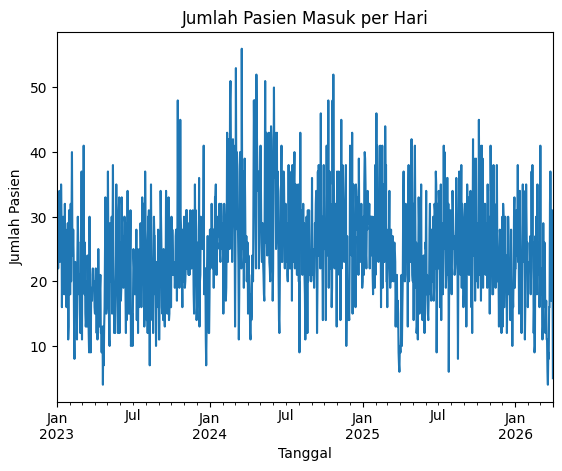

In [7]:
# Hitung jumlah pasien per hari
daily = df.groupby('tgl_masuk').size()

# Plot
plt.figure()
daily.plot()
plt.title('Jumlah Pasien Masuk per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Pasien')
plt.show()

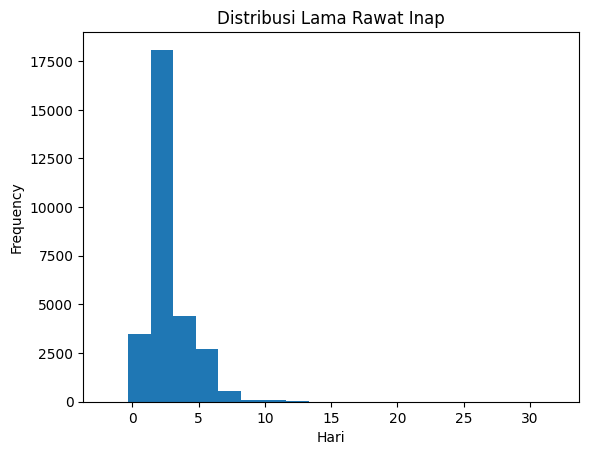

In [8]:
df['tgl_keluar'] = pd.to_datetime(df['tgl_keluar'])

df['lama_rawat'] = (df['tgl_keluar'] - df['tgl_masuk']).dt.days

df['lama_rawat'].plot(kind='hist', bins=20)
plt.title('Distribusi Lama Rawat Inap')
plt.xlabel('Hari')
plt.show()

4. Verify Data Quality

In [9]:
df.isnull().sum()

,0
no_register,0
no_rekam_medis,0
jenis_kelamin,0
umur,0
status_umur,0
tgl_masuk,0
tgl_keluar,0
kd_penyakit,3
nama_penyakit,3
tb_ralan,14461


#C. DATA PREPARATION

1. Select Data

In [10]:
df_selected = df[['no_register', 'tgl_masuk', 'tgl_keluar']].copy()

In [11]:
df_selected['tgl_masuk'] = pd.to_datetime(df_selected['tgl_masuk'])
df_selected['tgl_keluar'] = pd.to_datetime(df_selected['tgl_keluar'])

df_selected.head()

,no_register,tgl_masuk,tgl_keluar
0,2023/01/01/000002,2023-01-01,2023-01-02
1,2023/01/01/000003,2023-01-01,2023-01-04
2,2023/01/01/000004,2023-01-01,2023-01-06
3,2023/01/01/000005,2023-01-01,2023-01-03
4,2023/01/01/000006,2023-01-02,2023-01-04


In [12]:
df_selected.to_csv('/content/drive/MyDrive/skripsi/prediksi pasien/data_selected.csv', index=False)

2. Clean Data

In [13]:
df_selected.isnull().sum()

,0
no_register,0
tgl_masuk,0
tgl_keluar,0


In [14]:
df_selected.duplicated(subset=['no_register']).sum()

np.int64(484)

In [15]:
df_selected[
    df_selected.duplicated(keep=False)
].sort_values('no_register')

,no_register,tgl_masuk,tgl_keluar
14,2023/01/01/000023,2023-01-01,2023-01-03
15,2023/01/01/000023,2023-01-01,2023-01-03
22,2023/01/02/000231,2023-01-02,2023-01-06
23,2023/01/02/000231,2023-01-02,2023-01-06
26,2023/01/02/000306,2023-01-02,2023-01-06
...,...,...,...
29227,2026/03/22/000028,2026-03-22,2026-03-24
29248,2026/03/24/000034,2026-03-24,2026-03-27
29249,2026/03/24/000034,2026-03-24,2026-03-27
29446,2026/03/31/000672,2026-04-01,2026-04-03


In [16]:
df_selected = df_selected.drop_duplicates(subset=['no_register'])

In [17]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28975 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28975 non-null  object        
 1   tgl_masuk    28975 non-null  datetime64[ns]
 2   tgl_keluar   28975 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.5+ KB


In [18]:
df_selected[df_selected['tgl_keluar'] < df_selected['tgl_masuk']]\
.sort_values(by='tgl_masuk')

,no_register,tgl_masuk,tgl_keluar
1640,2023/03/14/000442,2023-03-14,2023-03-13
12426,2024/06/02/000056,2024-06-05,2024-06-03


In [19]:
df_selected = df_selected[df_selected['tgl_keluar'] >= df_selected['tgl_masuk']]

In [20]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28973 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28973 non-null  object        
 1   tgl_masuk    28973 non-null  datetime64[ns]
 2   tgl_keluar   28973 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.4+ KB


3. Construct Data

In [21]:
df_selected['tanggal'] = df_selected.apply(
    lambda row: pd.date_range(start=row['tgl_masuk'], end=row['tgl_keluar']),
    axis=1
)

df_exploded = df_selected.explode('tanggal')
daily = df_exploded.groupby('tanggal').size().reset_index(name='jumlah_pasien')

daily = daily.sort_values(by='tanggal').reset_index(drop=True)
daily.head(10)

,tanggal,jumlah_pasien
0,2023-01-01,13
1,2023-01-02,37
2,2023-01-03,62
3,2023-01-04,74
4,2023-01-05,86
5,2023-01-06,90
6,2023-01-07,85
7,2023-01-08,78
8,2023-01-09,103
9,2023-01-10,93


In [22]:
daily['is_weekend'] = daily['tanggal'].dt.weekday.isin([5,6]).astype(int)

In [23]:
daily[['tanggal','is_weekend']].head(10)

,tanggal,is_weekend
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,1
7,2023-01-08,1
8,2023-01-09,0
9,2023-01-10,0


In [24]:
years = range(2023, 2027)

indo_holidays = holidays.Indonesia(years=years)

In [25]:
holiday_df = pd.DataFrame(
    list(indo_holidays.items()),
    columns=['tanggal', 'nama_libur']
)

holiday_df.head(20)

,tanggal,nama_libur
0,2024-01-01,New Year's Day
1,2024-08-17,Independence Day
2,2024-12-25,Christmas Day
3,2024-04-10,Eid al-Fitr
4,2024-04-11,Eid al-Fitr Second Day
5,2024-06-17,Eid al-Adha
6,2024-02-08,Isra' and Mi'raj
7,2024-05-09,Ascension Day
8,2024-07-07,Islamic New Year
9,2024-09-16,Prophet's Birthday


In [26]:
def get_holiday_dates(keyword):
    return holiday_df[
        holiday_df['nama_libur'].str.contains(keyword, case=False, na=False)
    ]['tanggal'].tolist()

In [27]:
# Tahun Baru Imlek
imlek_dates = get_holiday_dates("Lunar New Year")

# Idul Fitri Hari Pertama
idul_fitri_dates = get_holiday_dates("^Eid al-Fitr$")

# Idul Fitri Hari Kedua
idul_fitri_sec_dates = get_holiday_dates("Eid al-Fitr Second Day")

# Idul Adha
idul_adha_dates = get_holiday_dates("Eid al-Adha")

# Hari Raya Waisak
waisak_dates = get_holiday_dates("Vesak")

# Hari Raya Natal
natal_dates = get_holiday_dates("Christmas")

# Hari Raya Nyepi
nyepi_dates = get_holiday_dates("Day of Silence")

In [28]:
daily['tanggal'] = pd.to_datetime(daily['tanggal'])

def add_event_range(df, event_dates, column_name,
                    days_before=7,
                    days_after=7):

    df[column_name] = 0

    for date in pd.to_datetime(event_dates):

        start = date - pd.Timedelta(days=days_before)
        end = date + pd.Timedelta(days=days_after)

        df.loc[
            (df['tanggal'] >= start) &
            (df['tanggal'] <= end),
            column_name
        ] = 1

    return df

In [29]:
daily = add_event_range(daily, imlek_dates, 'is_imlek')
daily = add_event_range(daily, idul_fitri_dates, 'is_idulfitri')
daily = add_event_range(daily, idul_fitri_sec_dates, 'is_idulfitri_sec')
daily = add_event_range(daily, idul_adha_dates, 'is_iduladha')
daily = add_event_range(daily, waisak_dates, 'is_waisak')
daily = add_event_range(daily, natal_dates, 'is_natal')
daily = add_event_range(daily, nyepi_dates, 'is_nyepi')

In [30]:
daily[['tanggal','is_imlek', 'is_idulfitri', 'is_idulfitri_sec', 'is_iduladha', 'is_waisak', 'is_waisak', 'is_waisak', 'is_nyepi']].head(50)

,tanggal,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_waisak,is_waisak,is_nyepi
0,2023-01-01,0,0,0,0,0,0,0,0
1,2023-01-02,0,0,0,0,0,0,0,0
2,2023-01-03,0,0,0,0,0,0,0,0
3,2023-01-04,0,0,0,0,0,0,0,0
4,2023-01-05,0,0,0,0,0,0,0,0
5,2023-01-06,0,0,0,0,0,0,0,0
6,2023-01-07,0,0,0,0,0,0,0,0
7,2023-01-08,0,0,0,0,0,0,0,0
8,2023-01-09,0,0,0,0,0,0,0,0
9,2023-01-10,0,0,0,0,0,0,0,0


In [31]:
daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)

/tmp/ipykernel_497/1191417220.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)


In [32]:
daily[['tanggal','is_libur_nasional']].head(20)

,tanggal,is_libur_nasional
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,0
7,2023-01-08,0
8,2023-01-09,0
9,2023-01-10,0


In [33]:
daily['lag_1'] = daily['jumlah_pasien'].shift(1)
daily['lag_7'] = daily['jumlah_pasien'].shift(7)
daily['lag_14'] = daily['jumlah_pasien'].shift(14)
daily['lag_21'] = daily['jumlah_pasien'].shift(21)
daily['lag_30'] = daily['jumlah_pasien'].shift(30)

daily = daily.dropna().reset_index(drop=True)

lag_columns = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_30']
daily[lag_columns] = daily[lag_columns].astype('int64')

Deteksi dan Hapus Outlier

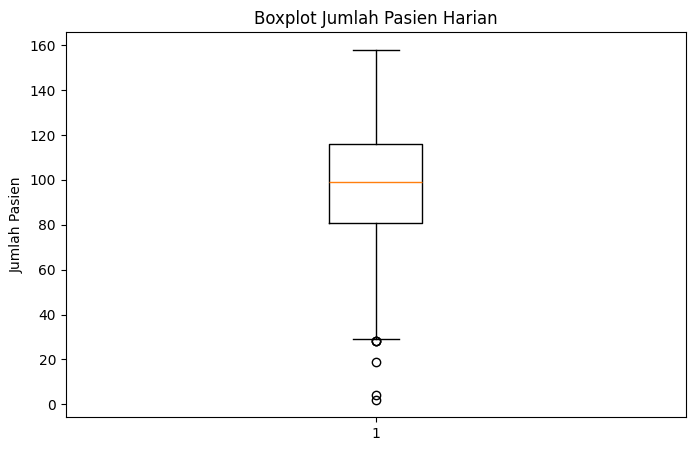

In [34]:
# Membuat boxplot
plt.figure(figsize=(8,5))

plt.boxplot(daily['jumlah_pasien'])

# Judul dan label
plt.title('Boxplot Jumlah Pasien Harian')
plt.ylabel('Jumlah Pasien')

# Tampilkan
plt.show()

In [35]:
Q1 = daily['jumlah_pasien'].quantile(0.25)
Q3 = daily['jumlah_pasien'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = daily[
    (daily['jumlah_pasien'] < lower_bound) |
    (daily['jumlah_pasien'] > upper_bound)
]

outlier

,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
789,2025-03-30,28,1,0,1,1,0,0,0,1,0,44,75,96,94,119
790,2025-03-31,28,0,0,1,1,0,0,0,1,1,28,77,101,111,105
1146,2026-03-22,28,1,0,1,1,0,0,0,1,1,29,88,68,87,85
1159,2026-04-04,19,1,0,0,0,0,0,0,0,0,30,123,29,86,92
1160,2026-04-05,4,1,0,0,0,0,0,0,0,1,19,119,28,88,82
1161,2026-04-06,2,0,0,0,0,0,0,0,0,0,4,127,36,78,76


In [36]:
daily = daily[
    (daily['jumlah_pasien'] >= lower_bound) &
    (daily['jumlah_pasien'] <= upper_bound)
].copy()

print("Jumlah data setelah menghapus outlier:", len(daily))

Jumlah data setelah menghapus outlier: 1156


4. Integrate Data

In [40]:
print(daily.shape)
daily.head()

(1156, 16)


,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
0,2023-01-31,70,0,0,0,0,0,0,0,0,0,69,91,94,93,13
1,2023-02-01,77,0,0,0,0,0,0,0,0,0,70,69,89,98,37
2,2023-02-02,69,0,0,0,0,0,0,0,0,0,77,68,79,91,62
3,2023-02-03,78,0,0,0,0,0,0,0,0,0,69,71,84,82,74
4,2023-02-04,79,1,0,0,0,0,0,0,0,0,78,57,80,77,86


In [41]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1156 entries, 0 to 1158
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal            1156 non-null   datetime64[ns]
 1   jumlah_pasien      1156 non-null   int64         
 2   is_weekend         1156 non-null   int64         
 3   is_imlek           1156 non-null   int64         
 4   is_idulfitri       1156 non-null   int64         
 5   is_idulfitri_sec   1156 non-null   int64         
 6   is_iduladha        1156 non-null   int64         
 7   is_waisak          1156 non-null   int64         
 8   is_natal           1156 non-null   int64         
 9   is_nyepi           1156 non-null   int64         
 10  is_libur_nasional  1156 non-null   int64         
 11  lag_1              1156 non-null   int64         
 12  lag_7              1156 non-null   int64         
 13  lag_14             1156 non-null   int64         
 14  lag_21       

In [43]:
daily.to_csv('/content/drive/MyDrive/skripsi/prediksi pasien/data_min_30_2.csv', index=False)

5. Format Data

In [42]:
df = pd.read_csv('/content/drive/MyDrive/skripsi/prediksi pasien/data_min_30_2.csv')

1. Input and Output

In [44]:
features = [

    'is_weekend',

    'is_imlek',
    'is_idulfitri',
    'is_idulfitri_sec',
    'is_iduladha',
    'is_waisak',
    'is_natal',
    'is_nyepi',

    'is_libur_nasional',

    'lag_1',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',
]

target = 'jumlah_pasien'


X = df[features]
y = df[target]

2. Split Dataset 70:30

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, train_size=0.7, test_size=0.3)

In [46]:
print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (809, 14)
Test : (347, 14)


In [47]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print(
    "Train:",
    X_train.index.min(),
    "sampai",
    X_train.index.max()
)

print(
    "Test:",
    X_test.index.min(),
    "sampai",
    X_test.index.max()
)

X_train : (809, 14)
X_test  : (347, 14)
y_train : (809,)
y_test  : (347,)
Train: 0 sampai 808
Test: 809 sampai 1155


3. Scaling

In [48]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

numerical_cols = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# TRAIN
X_train_scaled[numerical_cols] = scaler_X.fit_transform(
    X_train[numerical_cols]
)
y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
)

# TEST
X_test_scaled[numerical_cols] = scaler_X.transform(
    X_test[numerical_cols]
)
y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1,1)
)

In [49]:
print(X_train_scaled.head())

print(y_train_scaled[:5])

   is_weekend  is_imlek  is_idulfitri  is_idulfitri_sec  is_iduladha  \
0           0         0             0                 0            0   
1           0         0             0                 0            0   
2           0         0             0                 0            0   
3           0         0             0                 0            0   
4           1         0             0                 0            0   

   is_waisak  is_natal  is_nyepi  is_libur_nasional     lag_1     lag_7  \
0          0         0         0                  0  0.315385  0.484615   
1          0         0         0                  0  0.323077  0.315385   
2          0         0         0                  0  0.376923  0.307692   
3          0         0         0                  0  0.315385  0.330769   
4          0         0         0                  0  0.384615  0.223077   

     lag_14    lag_21    lag_30  
0  0.507692  0.500000  0.000000  
1  0.469231  0.538462  0.165517  
2  0.392308  0

4. Sliding Windows

In [50]:
TIME_STEPS = 30

def create_sequences(X, y, time_steps):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):
        Xs.append(
            X[i:(i+time_steps)]
        )
        ys.append(
            y[i+time_steps]
        )

    return np.array(Xs), np.array(ys)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)

In [51]:
print(X_train_seq.shape)
print(y_train_seq.shape)

print(X_test_seq.shape)
print(y_test_seq.shape)

(779, 30, 14)
(779, 1)
(317, 30, 14)
(317, 1)


In [52]:
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train_seq)):

    print(f'Fold {fold+1}')

    print(
        "Train:",
        len(train_idx)
    )

    print(
        "Validation:",
        len(val_idx)
    )

    print('-'*30)

Fold 1
Train: 134
Validation: 129
------------------------------
Fold 2
Train: 263
Validation: 129
------------------------------
Fold 3
Train: 392
Validation: 129
------------------------------
Fold 4
Train: 521
Validation: 129
------------------------------
Fold 5
Train: 650
Validation: 129
------------------------------


In [53]:
MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/data_save_preparation/gru"

os.makedirs(MODEL_PATH, exist_ok=True)

np.save(
    f"{MODEL_PATH}/X_train_seq.npy",
    X_train_seq
)

np.save(
    f"{MODEL_PATH}/y_train_seq.npy",
    y_train_seq
)

np.save(
    f"{MODEL_PATH}/X_test_seq.npy",
    X_test_seq
)

np.save(
    f"{MODEL_PATH}/y_test_seq.npy",
    y_test_seq
)

#D. MODELING

1. Create Model

In [ ]:
def build_gru_model(
    input_shape,
    units,
    dropout,
    learning_rate
):

    model = Sequential()

    model.add(
        Input(shape=input_shape)
    )

    model.add(
        GRU(
            units=units,
            return_sequences=False
        )
    )

    model.add(
        Dropout(dropout)
    )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss='mse',
        metrics=['mae']
    )

    return model

2. Hyperparameter Tuning with Oputna

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 15.4 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):

    # ======================
    # Hyperparameter Search
    # ======================

    units = trial.suggest_categorical(
        'units',
        [16, 32, 48, 64]
    )

    dropout = trial.suggest_float(
        'dropout',
        0.1,
        0.3
    )

    learning_rate = trial.suggest_float(
        'learning_rate',
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        'batch_size',
        [16, 32, 64]
    )

    tscv = TimeSeriesSplit(
        n_splits=5
    )

    mae_scores = []
    epoch_per_fold = []
    std_per_fold = []
    rmse_scores = []
    mape_scores = []
    wape_scores = []

    for train_idx, val_idx in tscv.split(
        X_train_seq
    ):

        X_fold_train = X_train_seq[train_idx]
        X_fold_val = X_train_seq[val_idx]

        y_fold_train = y_train_seq[train_idx]
        y_fold_val = y_train_seq[val_idx]

        model = Sequential()

        model = build_gru_model(
            input_shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            ),
            units=units,
            dropout=dropout,
            learning_rate=learning_rate
        )


        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        history = model.fit(
            X_fold_train,
            y_fold_train,
            validation_data=(
                X_fold_val,
                y_fold_val
            ),
            epochs=100,
            batch_size=batch_size,
            callbacks=[early_stop],
            shuffle=False,
            verbose=0
        )

        pred = model.predict(
            X_fold_val,
            verbose=0
        )

        pred = scaler_y.inverse_transform(
            pred
        )

        actual = scaler_y.inverse_transform(
            y_fold_val.reshape(-1,1)
        )

        mae = mean_absolute_error(
            actual,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(actual, pred)
        )

        mape = np.mean(
            np.abs((actual - pred) / actual)
        ) * 100

        wape = (
            np.sum(
                np.abs(actual - pred)
            )
            /
            np.sum(
                np.abs(actual)
            )
        ) * 100

        std_fold = np.std(
          history.history["val_mae"]
        )

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)
        wape_scores.append(wape)
        used_epoch = len(history.history["loss"])
        epoch_per_fold.append(used_epoch)
        std_per_fold.append(std_fold)

    mean_mae = np.mean(mae_scores)
    mean_rmse = np.mean(rmse_scores)
    mean_mape = np.mean(mape_scores)
    mean_wape = np.mean(wape_scores)

    trial.set_user_attr(
      "mean_rmse",
      mean_rmse
    )

    trial.set_user_attr(
      "mean_mape",
      mean_mape
    )

    trial.set_user_attr(
      "mean_mae",
      mean_mae
    )

    trial.set_user_attr(
        "mean_wape",
        mean_wape
    )

    trial.set_user_attr(
      "epoch_per_fold",
      epoch_per_fold
    )

    trial.set_user_attr(
      "std_per_fold",
      std_per_fold
    )

    return mean_mae

In [ ]:
# sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction='minimize',
)

start_time = time.time()

study.optimize(
    objective,
    n_trials=30
)

end_time = time.time()

optuna_time = end_time - start_time

print(f"Total waktu Optuna: {optuna_time:.2f} detik")
print(f"Total waktu Optuna: {optuna_time/60:.2f} menit")

[I 2026-08-15 11:30:45,457] A new study created in memory with name: no-name-38d20b70-ba58-45c5-9f89-536510c32784
[I 2026-08-15 11:34:38,793] Trial 0 finished with value: 14.097806643700414 and parameters: {'units': 48, 'dropout': 0.235388682668576, 'learning_rate': 0.00013851176186391816, 'batch_size': 16}. Best is trial 0 with value: 14.097806643700414.
[I 2026-08-15 11:36:20,986] Trial 1 finished with value: 12.685584412803944 and parameters: {'units': 32, 'dropout': 0.18062170374581688, 'learning_rate': 0.0007100967018911242, 'batch_size': 64}. Best is trial 1 with value: 12.685584412803944.
[I 2026-08-15 11:37:16,429] Trial 2 finished with value: 11.298823707048282 and parameters: {'units': 32, 'dropout': 0.12530067286863683, 'learning_rate': 0.0046547612606646005, 'batch_size': 64}. Best is trial 2 with value: 11.298823707048282.
[I 2026-08-15 11:38:55,343] Trial 3 finished with value: 12.71937966753346 and parameters: {'units': 64, 'dropout': 0.11753696649140838, 'learning_rate'

Total waktu Optuna: 2816.39 detik
Total waktu Optuna: 46.94 menit


In [ ]:
best_params = study.best_params
best_trial = study.best_trial

print(study.best_trial.number)
print(study.best_trial.number)
print(best_params)
print("Epoch tiap fold :")
print(best_trial.user_attrs["epoch_per_fold"])
print(best_trial.user_attrs["std_per_fold"])
print("MAE        :", best_trial.user_attrs["mean_mae"])
print("RMSE       :", best_trial.user_attrs["mean_rmse"])
print("MAPE       :", best_trial.user_attrs["mean_mape"])
print("WAPE       :", best_trial.user_attrs["mean_wape"], "%")

20
20
{'units': 64, 'dropout': 0.10073840667598549, 'learning_rate': 0.004335466376601002, 'batch_size': 16}
Epoch tiap fold :
[16, 25, 23, 22, 17]
[np.float64(0.008557239414445734), np.float64(0.011458952197183752), np.float64(0.029125534375133603), np.float64(0.03235806059365808), np.float64(0.010897822479627317)]
MAE        : 10.776533005588739
RMSE       : 13.567250728592054
MAPE       : 11.377417346863611
WAPE       : 10.60587800997087 %


3. Training Best Hyperparameter With Time Series Split

In [ ]:
# ==========================================
# Training Time Series Split
# ==========================================

histories = []
mae_scores = []
rmse_scores = []
mape_scores = []
wape_scores = []
training_times = []

fold = 1

for train_idx, val_idx in tscv.split(X_train_seq):

    print(f"\n========== Fold {fold} ==========")

    X_fold_train = X_train_seq[train_idx]
    X_fold_val   = X_train_seq[val_idx]

    y_fold_train = y_train_seq[train_idx]
    y_fold_val   = y_train_seq[val_idx]

    # ==========================================
    # Membuat Model
    # ==========================================

    model = build_gru_model(
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        ),
        units=best_params['units'],
        dropout=best_params['dropout'],
        learning_rate=best_params['learning_rate']
    )

    # ==========================================
    # Training
    # ==========================================

    start = time.time()

    history = model.fit(

        X_fold_train,

        y_fold_train,

        validation_data=(
            X_fold_val,
            y_fold_val
        ),

        epochs=15,

        batch_size=best_params['batch_size'],

        shuffle=False,

        verbose=1

    )

    end = time.time()

    elapsed = end - start

    training_times.append(elapsed)

    print(f"Fold {fold} : {elapsed:.2f} detik")

    histories.append(history.history)

    # ==========================================
    # Prediksi Data Validation
    # ==========================================

    pred_scaled = model.predict(
        X_fold_val,
        verbose=0
    )

    # Kembalikan ke skala asli
    pred = scaler_y.inverse_transform(pred_scaled)

    actual = scaler_y.inverse_transform(
        y_fold_val.reshape(-1, 1)
    )

    # ==========================================
    # Hitung Metrik
    # ==========================================

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mape = np.mean(
        np.abs((actual - pred) / actual)
    ) * 100

    wape = (
            np.sum(
                np.abs(actual - pred)
            )
            /
            np.sum(
                np.abs(actual)
            )
        ) * 100

    # Simpan skor
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    wape_scores.append(wape)

    # Tampilkan hasil tiap fold
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"WAPE : {wape:.2f}%")

    fold += 1


========== Fold 1 ==========
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0542 - mae: 0.1853 - val_loss: 0.0083 - val_mae: 0.0748
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0573 - mae: 0.1936 - val_loss: 0.0073 - val_mae: 0.0683
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0300 - mae: 0.1374 - val_loss: 0.0109 - val_mae: 0.0866
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0187 - mae: 0.1046 - val_loss: 0.0100 - val_mae: 0.0827
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0092 - mae: 0.0785 - val_loss: 0.0067 - val_mae: 0.0668
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0093 - mae: 0.0784 - val_loss: 0.0103 - val_mae: 0.0837
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0079 - mae: 0.0731 - val_loss: 0.0079 - val_mae: 0.0720
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0080 - mae: 0.0710 - val_loss: 0.0081 - val_mae: 0.0726
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step -

In [ ]:
print("\n========================================")
print("HASIL CROSS VALIDATION")
print("========================================")

print(f"Mean MAE  : {np.mean(mae_scores):.4f}")

print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")

print(f"Mean MAPE : {np.mean(mape_scores):.2f}%")

print(f"Mean WAPE : {np.mean(wape_scores):.2f}%")

print(f"\nRata-rata waktu training : {np.mean(training_times):.2f} detik")


HASIL CROSS VALIDATION
Mean MAE  : 12.1732
Mean RMSE : 15.3208
Mean MAPE : 12.92%
Mean WAPE : 12.03%

Rata-rata waktu training : 11.79 detik


In [ ]:
train_loss = np.mean(
    [h['loss'] for h in histories],
    axis=0
)

val_loss = np.mean(
    [h['val_loss'] for h in histories],
    axis=0
)

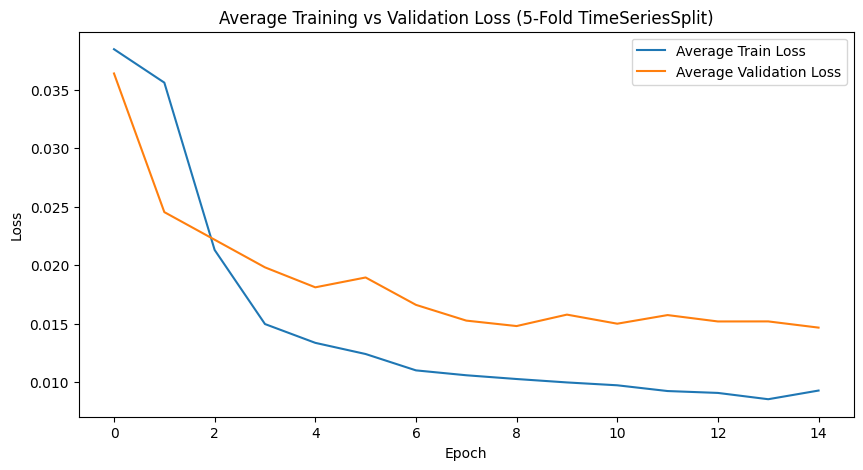

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    train_loss,
    label='Average Train Loss'
)

plt.plot(
    val_loss,
    label='Average Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Training vs Validation Loss (5-Fold TimeSeriesSplit)")
plt.legend()

plt.show()

4. Final Training

In [ ]:
model = build_gru_model(
      input_shape=(
        X_train_seq.shape[1],
        X_train_seq.shape[2]
      ),
      units=best_params['units'],
      dropout=best_params['dropout'],
      learning_rate=best_params['learning_rate']
)

start_time = time.time()

history = model.fit(

    X_train_seq,

    y_train_seq,

    epochs=15,

    batch_size=best_params['batch_size'],

    shuffle=False,

    verbose=1

)

end_time = time.time()

running_time = end_time - start_time

print(f"Running time: {running_time:.2f} detik")

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0347 - mae: 0.1448
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0165 - mae: 0.1003
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0149 - mae: 0.0937
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0148 - mae: 0.0975
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0177 - mae: 0.1057
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0176 - mae: 0.1051
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0195 - mae: 0.1125
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0208 - mae: 0.1186
Epoch 9/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0222 - mae: 0.1208
Epoch 10/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0219 - mae: 0.1195
Epoch 11/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0179 - mae: 0.1078
Epoch 12/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0145 - mae: 0.0972
Epoch 13/15
49/49 ━━━━━━━━━━━━━━━━━━━

5. Prediction With Data Test

In [ ]:
start = time.time()

pred_scaled = model.predict(
    X_test_seq
)

end = time.time()

print(f"Waktu prediksi: {end - start:.4f} detik")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Waktu prediksi: 0.5122 detik


In [ ]:
pred = scaler_y.inverse_transform(
    pred_scaled
)

In [ ]:
y_actual = scaler_y.inverse_transform(
    y_test_seq
)

5. Asses Model

In [ ]:
mae = mean_absolute_error(
    y_actual,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        pred
    )
)

mape = (
    mean_absolute_percentage_error(
        y_actual,
        pred
    ) *100
)

wape = (
        np.sum(
            np.abs(y_actual - pred)
        )
        /
        np.sum(
            np.abs(y_actual)
        )
    ) * 100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape,"%")
print("WAPE :", wape,"%")

MAE : 10.499688452350604
RMSE : 13.640669348176681
MAPE : 11.234184205503135 %
WAPE : 10.102289250599878 %


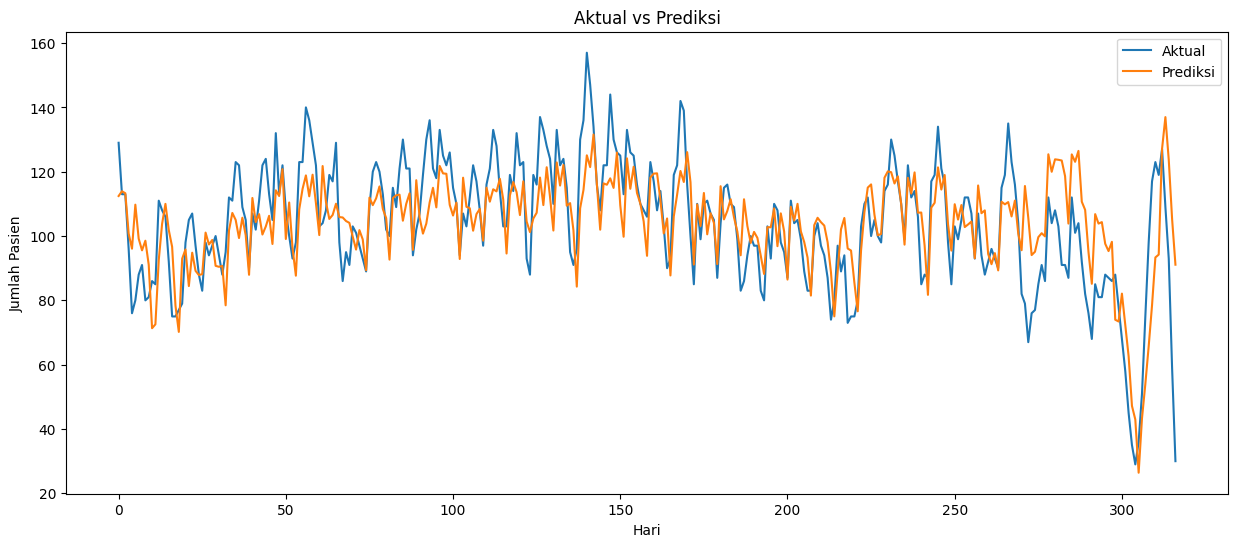

In [ ]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    y_actual,

    label='Aktual'

)

plt.plot(

    pred,

    label='Prediksi'

)

plt.xlabel('Hari')

plt.ylabel(
    'Jumlah Pasien'
)

plt.title(

    'Aktual vs Prediksi'

)

plt.legend()

plt.show()

#E. SAVE MODEL

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/model"

os.makedirs(MODEL_PATH, exist_ok=True)

In [ ]:
model.save(
    f"{MODEL_PATH}/gru_model2.keras"
)

In [ ]:
joblib.dump(
    scaler_X,
    f"{MODEL_PATH}/scaler_X.pkl"
)

joblib.dump(
    scaler_y,
    f"{MODEL_PATH}/scaler_y.pkl"
)